# Проект. Исследование стартапов

## Введение

Финансовая компания, занимающаяся венчурными инвестициями обратилась к нам за помощью. Заказчик хочет выбрать наиболее удачный бизнес для вложения средств. В датасете - множество стартапов и проектов, инновационных компаний. Наша задача - проанализировать данные и сделать обоснованный вывод с рекомендациями: куда лучше инвестировать для получения максимального профита.

## Шаг 1. Знакомство с данными: загрузка и предобработка

Название основного датасета — `cb_investments`. Внутри архива один файл — `cb_investments`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.


### 1.1. Вывод общей информации

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
df = pd.read_csv("Desktop/cb_investments.csv", sep=';', low_memory=False)

In [6]:
# Записываем второй датасет в другую переменную, так как нет ключа для соединения и разный смысл данных в датасетах
df_returns = pd.read_csv("https://code.s3.yandex.net/datasets/cb_returns.csv")

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [8]:
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
df_returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


In [10]:
df_returns.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


В датасете `df` содержится 54294 строки, но ни в одном столбце нет стольких непустых значений. Абсолютно все 40 столбцов содержат пропуски. Есть столбцы, которые имеют неподходящий тип данных: столбец `funding_total_usd` имеет тип `object`, когда разумнее использовать `float64`, для `founded_at` и `first_funding_at` - `datetime64`.

В датасете `df_returns` содержится 15 строк и 14 столбцов. При этом нигде нет пропусков. Типы данных корректно подобраны.

### 1.2. Предобработка данных

Нам необходимо только убрать пробелы в начале столбцов `market` и `funding_total_usd`, а также привести все столбцы с названием `round_X` в названию `round_x`, где X - конкретный раунд финансирования.

In [11]:
# Убираем пробелы в начале всех столбцов
df.columns = df.columns.str.strip()

In [12]:
# Переименуем столбцы с раундами финансирования
round_cols = []
for col in df.columns:
    if col.startswith('round_'):
        round_cols.append(col)
rename_round = {col: col.lower() for col in round_cols}
df = df.rename(columns=rename_round)

In [13]:
# Выведем информацию о датафрейме 'df', чтобы зафиксировать изменения
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3   market                45477 non-null  object 
 4   funding_total_usd     49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [14]:
# Напишем функцию, которая будет менять каждое числовое значение на значение без запятых, а тип данных автоматически приводить к 'float64'
def clean_value(x):
    if pd.notna(x) and str(x).strip() and str(x).strip()[0].isdigit():
        return float(str(x).replace(',', ''))
    return None

df['funding_total_usd'] = df['funding_total_usd'].apply(clean_value)

df.info()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3   market                45477 non-null  object 
 4   funding_total_usd     40907 non-null  float64
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
0,Harvard University,http://harvard.edu,|Education|,Education,90000000.0,operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,2000000.0,operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,7700000.0,operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,540000.0,operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54289,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


В процессе выполнения функции часть ненулевых значений стала пропусками, так как мы принудительно заменили все прочерки в данных на `NaN`. Количество превращенных в пропуски значений: 8531.

In [15]:
# Преобразуем каждый столбец в datetime
date_columns = ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [16]:
# Теперь преобразуем в специальные форматы столбцы 'founded_month' и 'founded_quarter'
df['founded_month'] = pd.to_datetime(df['founded_month'], errors='coerce').dt.to_period('M')

df['founded_quarter'] = pd.PeriodIndex(df['founded_quarter'], freq='Q')

In [17]:
# Выведем информацию для проверки изменений
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  49437 non-null  object        
 1   homepage_url          45989 non-null  object        
 2   category_list         45477 non-null  object        
 3   market                45477 non-null  object        
 4   funding_total_usd     40907 non-null  float64       
 5   status                48124 non-null  object        
 6   country_code          44165 non-null  object        
 7   state_code            30161 non-null  object        
 8   region                44165 non-null  object        
 9   city                  43322 non-null  object        
 10  funding_rounds        49438 non-null  float64       
 11  participants          30473 non-null  float64       
 12  founded_at            38553 non-null  datetime64[ns]
 13  founded_month   

Как видим, все столбцы с датами (или их частями) успешно приведены к релевантному типу данных.

In [18]:
# Перезапишем переменную датафрейма, чтобы установить индекс
df_returns = pd.read_csv('https://code.s3.yandex.net/datasets/cb_returns.csv', index_col='year')

In [19]:
# Сначала удалим все путсые строки без названия компании - они нам ни к чему
df = df.dropna(subset=['name'])

In [20]:
# Текстовые столбцы
text_columns = df.select_dtypes(include=['object']).columns.tolist()
print("Текстовые столбцы:", text_columns)

# Проверяем пропуски
for col in text_columns:
    sum_of_nan = df[col].isna().sum()
    print(f"{col}: {sum_of_nan} пропусков ({sum_of_nan/len(df)*100:.2f}%)")

Текстовые столбцы: ['name', 'homepage_url', 'category_list', 'market', 'status', 'country_code', 'state_code', 'region', 'city']
name: 0 пропусков (0.00%)
homepage_url: 3449 пропусков (6.98%)
category_list: 3961 пропусков (8.01%)
market: 3961 пропусков (8.01%)
status: 1314 пропусков (2.66%)
country_code: 5272 пропусков (10.66%)
state_code: 19276 пропусков (38.99%)
region: 5272 пропусков (10.66%)
city: 6115 пропусков (12.37%)


In [21]:
# Теперь поставим значения-заглушки для всех столбцов типа 'object', в которых есть пропуски
fill_values = {
    'homepage_url': 'uknown',
    'category_list': 'uknown',
    'market': 'uknown',
    'status': 'uknown',
    'country_code': 'uknown',
    'state_code': 'uknown',
    'region': 'uknown',
    'city': 'uknown'}
df = df.fillna(fill_values)

In [22]:
# В данных могут быть пробелы - поэтому на всякий случай их удалим
for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

In [23]:
# Посмотрим, сколько полных дубликатов
df.duplicated().sum()

0

Полных дубликатов 0, поэтому ничего удалять не нужно.

In [24]:
# Удалим все строки с пропусками в `funding_total_usd`
len_df_before = 49937
print(f'Количество строк до удаления: {len_df_before}')
df = df.dropna(subset=['funding_total_usd'])
print(f'Количество строк после удаления: {len(df)}')
print(f'Удалено строк: {len_df_before-len(df)}')

Количество строк до удаления: 49937
Количество строк после удаления: 40906
Удалено строк: 9031


In [25]:
# Удалим строки, где 'funding_total_usd' = 0, то есть нет информации о финансировании
df= df[df['funding_total_usd'] != 0]
print(f'Строк осталось: {len(df)}')

Строк осталось: 40906


Получается, таких строк нет, так как размер датафрейма не изменился

In [26]:
# Напишем цикл, который переберет все строки датафрейма 'df' и заменит значения в 'mid_funding_at'
for i in range(len(df)):
    first = df.iloc[i, 16]
    last = df.iloc[i, 18]
    
    if pd.notna(first) and pd.notna(last):
        df.iloc[i, 17] = first + (last - first) / 2
    else:
        df.iloc[i, 17] = pd.NaT

In [27]:
# Проверка количества непустых значений в целевом столбце
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 40906 entries, 0 to 49437
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  40906 non-null  object        
 1   homepage_url          40906 non-null  object        
 2   category_list         40906 non-null  object        
 3   market                40906 non-null  object        
 4   funding_total_usd     40906 non-null  float64       
 5   status                40906 non-null  object        
 6   country_code          40906 non-null  object        
 7   state_code            40906 non-null  object        
 8   region                40906 non-null  object        
 9   city                  40906 non-null  object        
 10  funding_rounds        40906 non-null  float64       
 11  participants          27331 non-null  float64       
 12  founded_at            32199 non-null  datetime64[ns]
 13  founded_month   

In [28]:
# Получим процент отброшенных данных
round((54294 - len(df)) / 54294 * 100, 2)

24.66

Изначально было 54294 строки, на данный момент датафрейм `df` содержит лишь 40906 строк.

Что было сделано:
- Удалены полностью пустые строки (без названия компаний они не нужны)
- Столбцы приведены к релевантному типу данных, обработаны пробелы в значениях столбцов, убран разделитель разрядов в столбце `founding_total_usd`
- В датафрейме `cb_returns` столбец `year` стал индексом (больше изменений не производилось)
- Пропуски в текстовых столбцах были заменены на значения-заглушки `uknown`
- Переименованы столбцы с конкретным раундом финансирования (теперь в нижнем регистре)
- Удалены строки, где значение столбца `funding_total_usd` равно 0 или есть пропуски
- Пропуски в столбце `mid_funding_at` были заполнены в соответствии со значениями в столбцах `first_funding_at` и `last_funding_at` (медиана значений).

Данных для решения задач проекта достаточно, датафреймы приведены к надлежащему виду.

Было отброшено 24,66% данных (более половины из которых - заведомо пустые строки, фактически, отсутствие данных).

## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

Разделим все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируем соотношение этих групп, создав два графика:

* По количеству компаний: Покажем, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразим, какую долю от общего объёма привлечённых средств получила каждая группа.

In [29]:
df['first_funding_at'] = pd.to_datetime(df['first_funding_at'], errors='coerce')
df['last_funding_at'] = pd.to_datetime(df['last_funding_at'], errors='coerce')

dates = df['first_funding_at'].notna() & df['last_funding_at'].notna()
time_diff = (df['last_funding_at'] - df['first_funding_at']).dt.days

group_single = df[df['funding_rounds'] == 1]

condition_up_to_year = (dates & (time_diff <= 365) & (df['funding_rounds'] != 1))
group_up_to_year = df[condition_up_to_year]
condition_more_year = (
    dates & 
    (time_diff > 365) & 
    (df['funding_rounds'] != 1)
)
group_more_year = df[condition_more_year]

count_single = len(group_single)
count_up_to_year = len(group_up_to_year)
count_more_year = len(group_more_year)

# Всего компаний
total_companies = count_single + count_up_to_year + count_more_year

# Проценты
percent_single = (count_single / total_companies) * 100
percent_up_to_year = (count_up_to_year / total_companies) * 100
percent_more_year = (count_more_year / total_companies) * 100

funding_single = group_single['funding_total_usd'].sum()
funding_up_to_year = group_up_to_year['funding_total_usd'].sum()
funding_more_year = group_more_year['funding_total_usd'].sum()
total_funding = funding_single + funding_up_to_year + funding_more_year

percent_funding_single = (funding_single / total_funding) * 100
percent_funding_up_to_year = (funding_up_to_year / total_funding) * 100
percent_funding_more_year = (funding_more_year / total_funding) * 100


categories = ['Единичное финансирование', 'Срок до года', 'Срок более года']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

data_count = [percent_single, percent_up_to_year, percent_more_year]
data_funding = [percent_funding_single, percent_funding_up_to_year, percent_funding_more_year]

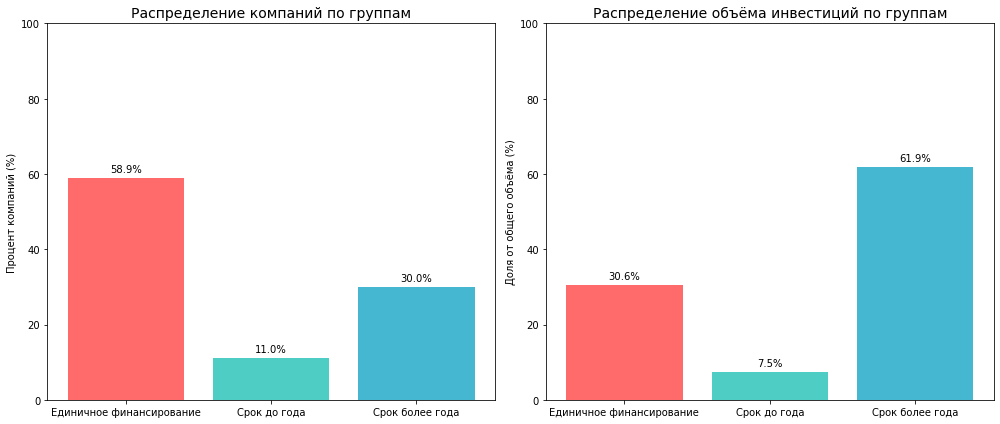

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# График 1: Процент компаний
bars1 = ax1.bar(categories, data_count, color=colors)
ax1.set_title('Распределение компаний по группам', fontsize=14)
ax1.set_ylabel('Процент компаний (%)')
ax1.set_ylim(0, 100)
ax1.tick_params(axis='x', rotation=0)

# Подписи значений на столбцы
for bar, val in zip(bars1, data_count):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

# График 2: Процент объёма инвестиций
bars2 = ax2.bar(categories, data_funding, color=colors)
ax2.set_title('Распределение объёма инвестиций по группам', fontsize=14)
ax2.set_ylabel('Доля от общего объёма (%)')
ax2.set_ylim(0, 100)
ax2.tick_params(axis='x', rotation=0)

# Подписи значений на столбцы
for bar, val in zip(bars2, data_funding):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

1-ый график

Как видно из визуализации, меньше всего компаний-стартапов со сроком финансирования до года (11%), что может быть связано с массовой краткосрочной потребностью в финансировании или ограничениями в бюджетных средствах.

Единичное финансирование востребовано, порядка 59% всех рассматриваемых компаний нуждались единожды в крупной сумме денег для запуска продукта. Это подтверждает, что компании - именно новички на рынке со своими амбициозными "дорогими" идеями.

Однако есть всего 30% компаний со сроком финансирования более года, что говорит о длительном цикле разработки продукта и возможном масштабировании, а, быть может, о долгосрочных обязательствах перед инвесторами.

2-ой график

Для тех компаний, у которых финансирование проводилось лишь раз, мы видим всего 30,6% инвестиций от общего обёма. Скорее всего, это проекты, которые только вышли на рынок; это небольшие стартапы без необходимости долго поддерживать проект деньгами. Новички пока не отладили все процессы и не исправляют недостатки, им сперва нужно себя показать. Потребность в больших раундах финансирования, вероятно, возрастет со временем при условии, что компания действительно перспективная.

Для компаний со сроком финансирования до года картина иная: лишь 7,5% инвестиций идет сюда. Для того, чтобы финансировать проект год (по тем или иным причинам), очевидно, необходимо меньше средств, чем тем стартапам, которым инвестиции нужны чаще.

Компании со сроком финансирования более года берут на себя большинство - около 62% абсолютно всех инвестиций в стартапы. Таким компаниям нужно больше средств для поддержания процессов и введения инноваций, разработку новых идей. Скорее всего это хорошие проекты, которые "играют вдолгую" и планируют стремительно развиваться.

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитаем, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесем к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесем к средним, а сегменты до 35 компаний отнесем к нишевым. Рассчитаем, сколько сегментов попадает в каждую из категорий.

Построим график распределения количества компаний в сегментах и отобразим на нём разделение на нишевые и средние сегменты.

In [31]:
# Частота каждого сегмента
market_frequency = df['market'].value_counts()

# Разобьем на группы
mass = market_frequency[market_frequency > 120]
mid = market_frequency[(market_frequency >= 35) & (market_frequency <= 120)]
niche = market_frequency[market_frequency < 35]

# Посмотрим, сколько сегментов в каждой группе
print('СТАТИСТИКА ПО СЕГМЕНТАМ РЫНКА')
print(f'\nМассовые сегменты (>120 компаний): {len(mass)} сегментов ({round(len(mass)/len(market_frequency)*100, 2)}%)')
print(f'Средние сегменты (35-120 компаний): {len(mid)} сегментов ({round(len(mid)/len(market_frequency)*100, 2)}%)')
print(f'Нишевые сегменты (<35 компаний): {len(niche)} сегментов ({round(len(niche)/len(market_frequency)*100, 2)}%)')
print(f'Всего: {len(market_frequency)} сегментов')

print('\nРАСПРЕДЕЛЕНИЕ КОМПАНИЙ ПО СЕГМЕНТАМ')

# Сколько компаний в каждой группе сегментов
companies_in_mass = mass.sum()
companies_in_mid = mid.sum()
companies_in_niche = niche.sum()
total_companies_segments = companies_in_mass + companies_in_mid + companies_in_niche

print(f'\nКомпаний в массовых сегментах: {companies_in_mass} ({round(companies_in_mass/total_companies_segments*100, 2)}%)')
print(f'Компаний в средних сегментах: {companies_in_mid} ({round(companies_in_mid/total_companies_segments*100, 2)}%)')
print(f'Компаний в нишевых сегментах: {companies_in_niche} ({round(companies_in_niche/total_companies_segments*100, 2)}%)')
print(f'Всего компаний (с указанным market): {total_companies_segments}')

СТАТИСТИКА ПО СЕГМЕНТАМ РЫНКА

Массовые сегменты (>120 компаний): 49 сегментов (12.41%)
Средние сегменты (35-120 компаний): 57 сегментов (14.43%)
Нишевые сегменты (<35 компаний): 289 сегментов (73.16%)
Всего: 395 сегментов

РАСПРЕДЕЛЕНИЕ КОМПАНИЙ ПО СЕГМЕНТАМ

Компаний в массовых сегментах: 36235 (88.58%)
Компаний в средних сегментах: 3841 (9.39%)
Компаний в нишевых сегментах: 830 (2.03%)
Всего компаний (с указанным market): 40906


Большинство сегментов (73.16%) являются нишевыми, но они охватывают лишь 2.03% компаний. Напротив, 49 массовых сегментов (всего 12.41% от всех сегментов) содержат 88.58% всех компаний. Это указывает на высокую концентрацию стартапов в ограниченном числе популярных ниш.

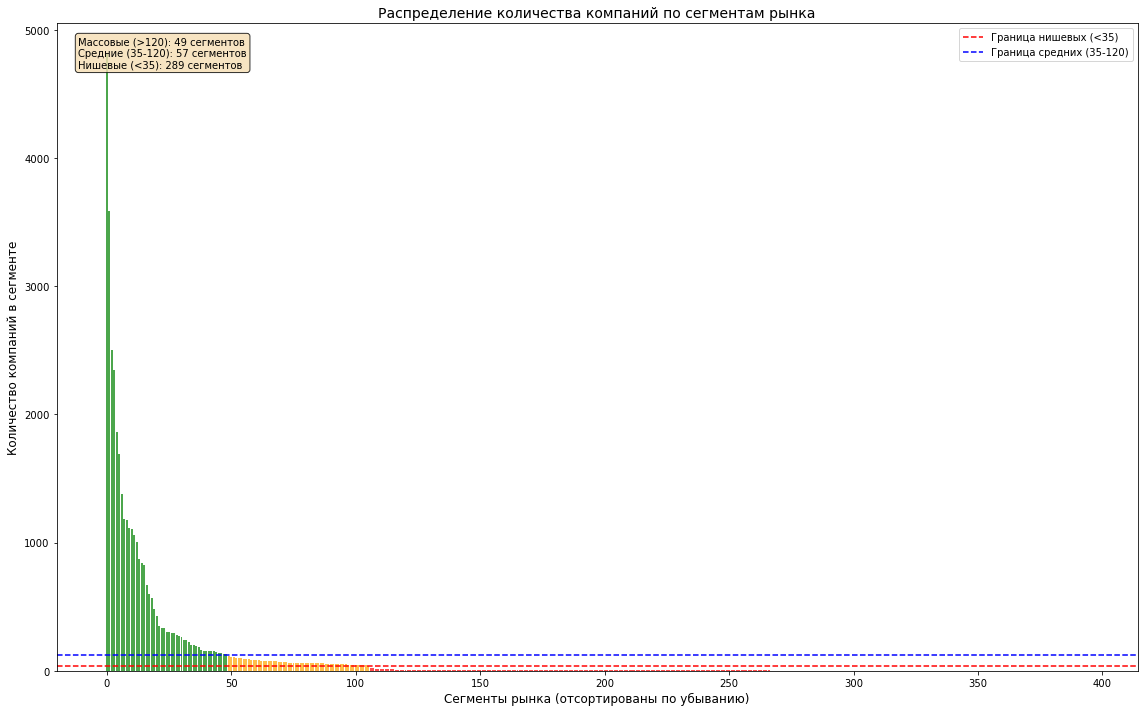

In [32]:
colors = []
market_frequency_sorted = df['market'].value_counts(ascending=False)
for count in market_frequency_sorted:
    if count < 35:
        colors.append('red')
    elif count <= 120:
        colors.append('orange')
    else:
        colors.append('green')

# Строим график
plt.figure(figsize=(16, 10))

plt.bar(range(len(market_frequency_sorted)), market_frequency_sorted.values, color=colors, alpha=0.7)

plt.axhline(y=35, color='red', linestyle='--', linewidth=1.5, label='Граница нишевых (<35)')
plt.axhline(y=120, color='blue', linestyle='--', linewidth=1.5, label='Граница средних (35-120)')

plt.title('Распределение количества компаний по сегментам рынка', fontsize=14)
plt.xlabel('Сегменты рынка (отсортированы по убыванию)', fontsize=12)
plt.ylabel('Количество компаний в сегменте', fontsize=12)
plt.legend(loc='upper right')

# Добавляем аннотацию с числами
plt.text(0.02, 0.98, 
         f'Массовые (>120): {len(mass)} сегментов\nСредние (35-120): {len(mid)} сегментов\nНишевые (<35): {len(niche)} сегментов', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

На данном графике видно, что большинство компаний сосредоточено в сегменте массовых компаний. Компании из средних и нишевых сегментов очень сильно распределены между огромным числом сегментов, которых 395. Они редко встречаются в целом из-за специфики таких компаний.

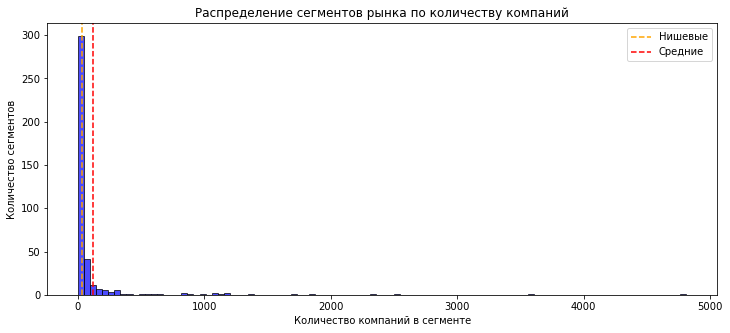

Всего сегментов: 395
Массовых: 49
Средних: 57
Нишевых: 289


In [34]:
# Гистограмма распределения сегментов рынка по количеству компаний
plt.figure(figsize=(12, 5))
plt.hist(market_frequency, bins=100, edgecolor='black', alpha=0.7, color='blue')
plt.axvline(x=35, color='orange', linestyle='--', label='Нишевые')
plt.axvline(x=120, color='red', linestyle='--', label='Средние')

plt.title('Распределение сегментов рынка по количеству компаний')
plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Количество сегментов')
plt.legend()
plt.show()

print(f'Всего сегментов: {len(market_frequency)}')
print(f'Массовых: {len(mass)}')
print(f'Средних: {len(mid)}')
print(f'Нишевых: {len(niche)}')

Гистограмма позволяет увидеть, что распределение сегментов рынка по количеству компаний скошено вправо: очень мало компаний находятся в большом количестве сегментов. Иными словами, на большое число сегментов приходится мало стартапов.

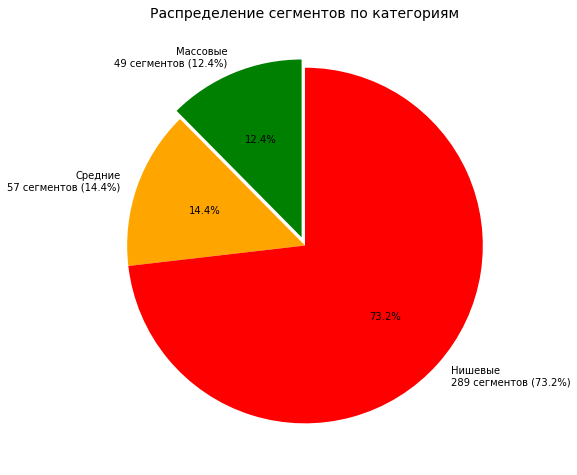

In [35]:
# Круговая диаграмма: доля сегментов по категориям
plt.figure(figsize=(8, 8))
sizes = [len(mass), len(mid), len(niche)]
labels = [f'Массовые\n{len(mass)} сегментов ({round(len(mass)/len(market_frequency)*100, 1)}%)',
          f'Средние\n{len(mid)} сегментов ({round(len(mid)/len(market_frequency)*100, 1)}%)',
          f'Нишевые\n{len(niche)} сегментов ({round(len(niche)/len(market_frequency)*100, 1)}%)']
colors_pie = ['green', 'orange', 'red']

plt.pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%', startangle=90, explode=(0.05, 0, 0))
plt.title('Распределение сегментов по категориям', fontsize=14)
plt.tight_layout()
plt.show()

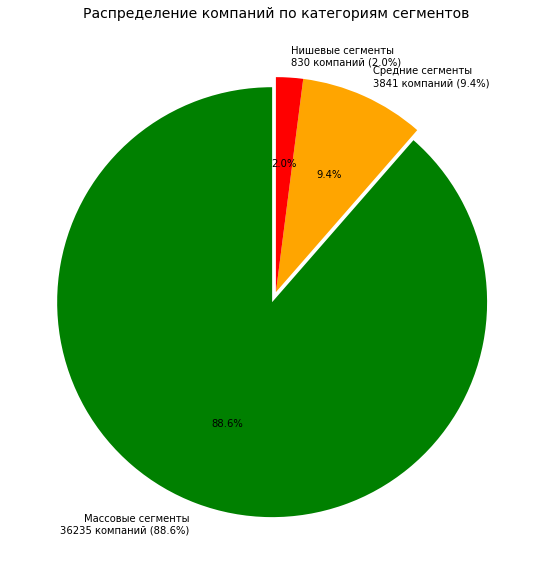

In [36]:
# Круговая диаграмма: доля компаний в каждой категории
plt.figure(figsize=(8, 8))
sizes_companies = [companies_in_mass, companies_in_mid, companies_in_niche]
labels_companies = [f'Массовые сегменты\n{companies_in_mass} компаний ({round(companies_in_mass/total_companies_segments*100, 1)}%)',
                    f'Средние сегменты\n{companies_in_mid} компаний ({round(companies_in_mid/total_companies_segments*100, 1)}%)',
                    f'Нишевые сегменты\n{companies_in_niche} компаний ({round(companies_in_niche/total_companies_segments*100, 1)}%)']

plt.pie(sizes_companies, labels=labels_companies, colors=colors_pie, autopct='%1.1f%%', startangle=90, explode=(0.05, 0, 0))
plt.title('Распределение компаний по категориям сегментов', fontsize=14)
plt.tight_layout()
plt.show()

Ключевые наблюдения:
- Нишевых сегментов большинство (73.2%), но они охватывают лишь 2.0% компаний.
- Массовых сегментов мало (12.4%), но они концентрируют 88.6% всех стартапов.
   
Распределение компаний по сегментам сильно скошено вправо. Это классический паттерн для рынков стартапов: небольшое количество популярных направлений (массовые сегменты) привлекают большинство игроков, в то время как множество нишевых направлений заполнены единичными компаниями.

Причины, по которым это помогает развиваться рынку стартапов:
- Диверсификация рисков: средства распределяются между разными сегментами, снижая зависимость от одного направления.
- Возможность роста: нишевые сегменты могут вырасти до массовых, создавая новые точки роста для экосистемы.
- Инновационный потенциал: нишевые сегменты часто являются новыми, зарождающимися рынками (например ИИ, blockchain в недавнем прошлом).
- Целевое инвестирование: инвесторы могут выбирать стратегию: работать с проверенными массовыми сегментами или искать "золото" в нишах.

Рекомендации ивесторам: диверсифицировать портфель между массовыми (стабильность) и нишевыми (потенциально высокий рост) сегментами.

Оставим в столбце `market` только массовые сегменты. Для остальных сегментов заменим значения на заглушки — `niche` для нишевых и `mid` для средних.

Дальнейшие исследования выполняйте с учётом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматривать не будем — они объединяются в два общих сегмента.


In [37]:
# Напишем цикл, который ставит заглушки
for group, count in market_frequency.items():
    if count > 120:
        continue
    elif count >= 35:
        df['market'] = df['market'].replace(group, 'mid')
    else:
        df['market'] = df['market'].replace(group, 'niche')
# Проверим
df['market']

0        Education
1           uknown
2              mid
3        Education
4        Education
           ...    
49433       uknown
49434        niche
49435       uknown
49436       uknown
49437     Startups
Name: market, Length: 40906, dtype: object

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу `funding_total_usd` графическим образом оценим, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажем интервал, в котором лежат типичные значения.

In [39]:
# Посмотрим на распределение
print(df['funding_total_usd'].describe())

count    4.090600e+04
mean     1.591291e+07
std      1.686808e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64


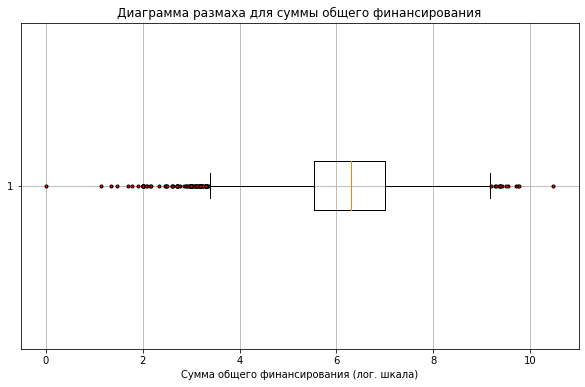

In [41]:

plt.figure(figsize=(10, 6))
bp = plt.boxplot(np.log10(df['funding_total_usd'].dropna()), vert=False,
                  flierprops=dict(markerfacecolor='red', marker='o', markersize=3))
plt.title('Диаграмма размаха для суммы общего финансирования')
plt.xlabel('Сумма общего финансирования (лог. шкала)')
plt.grid(True)

plt.show()


Построили именно логарифмическую шкалу, так как разброс между медианой и максимальными значениями слишком большой. 

Медианное значение для суммы общего финансирования находится на отметке 2 млн долларов, а типичные значения лежат в диапазоне от 1,8 тыс до 1,26 млрд долларов. При этом выбросы (минимальные) варьируются от 1 до около 1,8, а максимальные выбросы лежат в пределах от примерно 1,26 млрд до 30,08 млрд (все в долларах).

Определим компании с аномальным объёмом общего финансирования — используем метод IQR отдельно по каждому сегменту. Напомним, что все нишевые сегменты должны быть объединены в одну группу, а средние — в другую.

Определим сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведем топ таких сегментов.

In [42]:
# Напишем функцию для поиска аномальных значений
def find_outliers_iqr(group):
    q1 = group['funding_total_usd'].quantile(0.25)
    q3 = group['funding_total_usd'].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return (group['funding_total_usd'] < lower_bound) | (group['funding_total_usd'] > upper_bound)

In [43]:
# Сруппируем по 'market' и определяем аномалии
df['is_outlier'] = df.groupby('market', group_keys=False).apply(find_outliers_iqr)

# Проверим вывод
print(f"Всего аномальных компаний: {df['is_outlier'].sum()}")
print(f"Доля аномалий: {df['is_outlier'].mean()*100:.2f}%")

Всего аномальных компаний: 5244
Доля аномалий: 12.82%


In [44]:
# Здесь посчитаем долю аномальных компаний в каждом сегменте
outlier_share = df.groupby('market').agg(total_companies=('funding_total_usd', 'count'), outliers=('is_outlier', 'sum'))
outlier_share['outlier_pct'] = (outlier_share['outliers'] / outlier_share['total_companies']) * 100
outlier_share = outlier_share.sort_values('outlier_pct', ascending=False)

# Посмотрим результат
print('Топ-10 сегментов по доле аномального финансирования:')
print(outlier_share.head(10))

Топ-10 сегментов по доле аномального финансирования:
                 total_companies  outliers  outlier_pct
market                                                 
Real Estate                  279        48    17.204301
Entertainment                150        25    16.666667
Consulting                   349        58    16.618911
Search                       291        48    16.494845
Cloud Computing              152        25    16.447368
Photography                  204        33    16.176471
SaaS                         272        44    16.176471
Technology                   238        38    15.966387
Video                        188        30    15.957447
niche                        830       132    15.903614


In [45]:
# Исключим 'mid' и 'niche' и посмортим только массовые сегменты
massive_outliers = outlier_share[~outlier_share.index.isin(['mid', 'niche'])]
print('Топ-10 массовых сегментов по доле аномалий:')
print(massive_outliers.head(10))

Топ-10 массовых сегментов по доле аномалий:
                 total_companies  outliers  outlier_pct
market                                                 
Real Estate                  279        48    17.204301
Entertainment                150        25    16.666667
Consulting                   349        58    16.618911
Search                       291        48    16.494845
Cloud Computing              152        25    16.447368
Photography                  204        33    16.176471
SaaS                         272        44    16.176471
Technology                   238        38    15.966387
Video                        188        30    15.957447
Travel                       330        51    15.454545


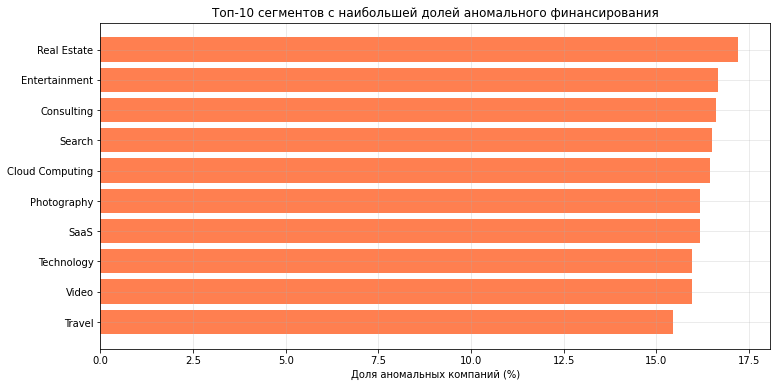

In [46]:
# Теперь сделаем визуализацию топ-10 массовых сегментов по доле аномалий
top10 = massive_outliers.head(10)
plt.figure(figsize=(12, 6))
plt.barh(range(len(top10)), top10['outlier_pct'], color='coral')
plt.yticks(range(len(top10)), top10.index)
plt.xlabel('Доля аномальных компаний (%)')
plt.title('Топ-10 сегментов с наибольшей долей аномального финансирования')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.show()

Все нишевые сегменты объединены в одну группу, а средние - в другую. Из диаграммы видно, что у топ-10 сегментов с наибольшей долей аномального финансирования не сильно различается процент аномалий. Больше всего аномалиям подвержено финансирование именно в сегменте недивижимости - связано это, скорее всего, со спецификой ниши: бывает элитная недвижимость с соответствующими огромными ценами. В целом видно, что сегменты с 15%+ аномальных выбросов так или иначе связаны с технологиями или хобби/развлечениями.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверим по датасету, можно ли считать, что нам предоставили полные данные за 2014 год. Затем исключим из датасета компании, которые мы ранее посчитали получившими аномальное финансирование.

Когда исключим аномальные записи, на основе столбцов `mid_funding_at` и `funding_rounds` оставим в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [47]:
# Посмотрим количество раундов финансирования по годам
df['funding_year'] = df['mid_funding_at'].dt.year
funding_by_year = df.groupby('funding_year').size()
print(funding_by_year.tail(10))

funding_year
2005.0     780
2006.0    1277
2007.0    1653
2008.0    2124
2009.0    3062
2010.0    4139
2011.0    5008
2012.0    6591
2013.0    8533
2014.0    7258
dtype: int64


Данные за 2014 год предоставили репрезентативные. Разница между 2013 и 2014 годом невелика (менее 20%).


2013 год: 8533 раундов
2014 год: 7258 раундов
Помесячное распределение раундов (2013-2014)
funding_month  1.0   2.0   3.0   4.0   5.0   6.0   7.0   8.0   9.0   10.0  \
funding_year                                                                
2013.0          732   542   688   630   621   696   763   753   801   756   
2014.0          915   723   798   742   646   762   709   569   554   502   

funding_month  11.0  12.0  
funding_year               
2013.0          783   768  
2014.0          315    23  


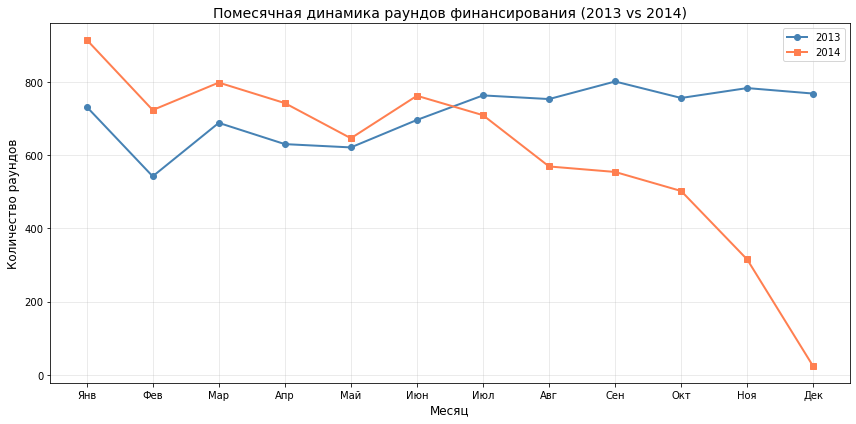

In [48]:
# Создаём столбец с годом и месяцем из mid_funding_at
df['funding_year'] = df['mid_funding_at'].dt.year
df['funding_month'] = df['mid_funding_at'].dt.month
df['funding_year_month'] = df['mid_funding_at'].dt.to_period('M')

# Количество раундов по годам
print(f'\n2013 год: {funding_by_year.get(2013, 0)} раундов')
print(f'2014 год: {funding_by_year.get(2014, 0)} раундов')

# Фильтруем данные за 2013 и 2014 годы
df_2013_2014 = df[df['funding_year'].isin([2013, 2014])]

# Группируем по году и месяцу
monthly_counts = df_2013_2014.groupby(['funding_year', 'funding_month']).size().unstack(fill_value=0)

print('Помесячное распределение раундов (2013-2014)')
print(monthly_counts)

plt.figure(figsize=(12, 6))

months = range(1, 13)

# Строим график для 2013 года
if 2013 in monthly_counts.index:
    plt.plot(months, monthly_counts.loc[2013], 
             marker='o', linewidth=2, label='2013', color='steelblue')

# Строим график для 2014 года
if 2014 in monthly_counts.index:
    plt.plot(months, monthly_counts.loc[2014], 
             marker='s', linewidth=2, label='2014', color='coral')

plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Количество раундов', fontsize=12)
plt.title('Помесячная динамика раундов финансирования (2013 vs 2014)', fontsize=14)
plt.xticks(months, ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 
                    'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Данные за 2014 год нельзя считать полными, так как в конце 2014 года наблюдается резкий спад количества раундов финансирования по сравнению с концом 2013 года. Поэтому 2014 год надо анализировать с другими годами с осторожностью.

In [49]:
# Удаляем компании с аномальным финансированием
df_clean = df[~df['is_outlier']].copy()
print(f'Было компаний: {len(df)}')
print(f'Стало после удаления аномалий: {len(df_clean)}')
print(f'Удалено аномальных: {len(df) - len(df_clean)}')
print(f'Процент удаленных компаний: {round((len(df) - len(df_clean)) / len(df), 3)*100}%')

Было компаний: 40906
Стало после удаления аномалий: 35662
Удалено аномальных: 5244
Процент удаленных компаний: 12.8%


In [50]:
# Считаем раунды по годам
funding_by_year = df_clean.groupby('funding_year').size()

# Находим первый год с 50+ раундами
first_active_year = funding_by_year[funding_by_year >= 50].index.min()
print(f'Первый год с 50+ раундами: {first_active_year}')

# Оставляем все годы с первого активного
active_years_continuous = range(int(first_active_year), int(funding_by_year.index.max()) + 1)
df_final = df_clean[df_clean['funding_year'].isin(active_years_continuous)].copy()

print(f"Годы в финальном датасете: {sorted(df_final['funding_year'].unique())}")

Первый год с 50+ раундами: 2000.0
Годы в финальном датасете: [2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0]


Итак, в этой части проекта мы оценили полноту данных в датасете за 2014 год, а также удалили компании, которые мы посчитали аномальными в прошлой части проекта (на основе метода IQR). Мы избавились более чем от одной восьмой части данных.

### 3.3. Анализ типов финансирования по объёму и популярности

Построим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Будем ориентироваться на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также построим график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравним графики и выделим часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

In [51]:
# Список типов финансирования
funding_types = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 
                 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']


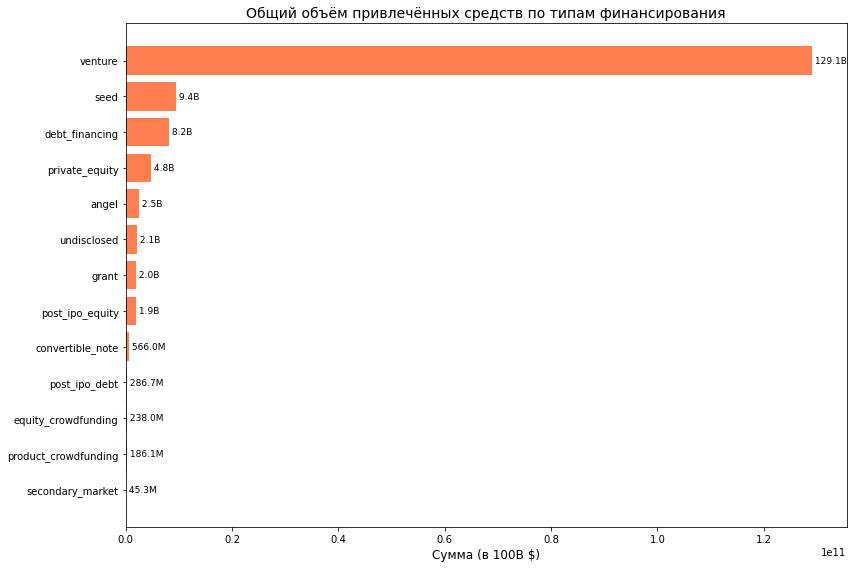

In [52]:
# Строим линейчатую диаграмму
total_by_type = df_final[funding_types].sum().sort_values(ascending=True)
plt.figure(figsize=(12, 8))
bars = plt.barh(total_by_type.index, total_by_type.values, color='coral')

# Напишем функцию, которая отформатирует метки денег
def format_money(value):
    if value >= 1e9:
        return f'{value/1e9:.1f}B'
    elif value >= 1e6:
        return f'{value/1e6:.1f}M'
    else:
        return f'{value/1e3:.0f}K'
# Цикл для добавления подписей
for bar, value in zip(bars, total_by_type.values):
    plt.text(value, bar.get_y() + bar.get_height()/2, f' {format_money(value)}', va='center', ha='left', fontsize=9)
plt.title('Общий объём привлечённых средств по типам финансирования', fontsize=14)
plt.xlabel('Сумма (в 100B $)', fontsize=12)
plt.tight_layout()
plt.show()

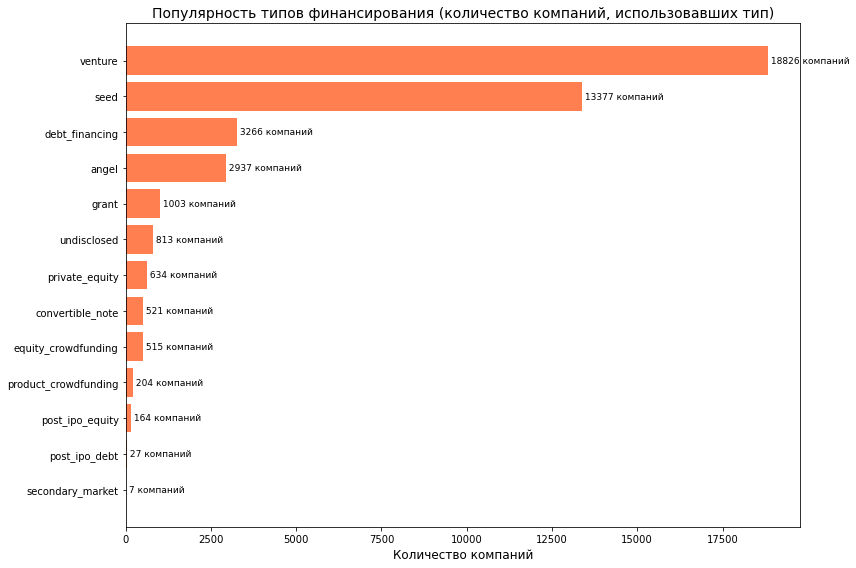

In [53]:
# Считаем, сколько компаний использовали каждый тип
popularity = (df_final[funding_types] > 0).sum().sort_values(ascending=True)
plt.figure(figsize=(12, 8))
bars = plt.barh(popularity.index, popularity.values, color='coral')
# Цикл для добавления подписей
for bar, value in zip(bars, popularity.values):
    plt.text(value, bar.get_y() + bar.get_height()/2, f' {value} компаний', va='center', ha='left', fontsize=9)
plt.title('Популярность типов финансирования (количество компаний, использовавших тип)', fontsize=14)
plt.xlabel('Количество компаний', fontsize=12)
plt.tight_layout()
plt.show()

На графиках видно, что венчурные инвестиции - абсолютный лидер как по объёмам привлечённых средств, так и по популярности. 

При этом можно заметить, что тип `seed` очень часто встречается (у 13377 компаний), однако объём привлечённых средств тут небольшой - всего 9,4 млрд. То же можно сказать про тип `angel`: при объёме в 2,5 млрд он входит в топ-4 по популярности (2937 компаний использовали данный тип).

Если говорить о типах финансирования, которые привлекли, наоборот, много средств, но при этом редко встречаются, то среди них можно отметить тип `post_ipo_equity`, который привлёк более 1,9 млрд ивестиций, но имеет малую популярность среди компаний: 164. Есть ещё тип `private_equity` с размером средств около 4,8 млрд, но с крайне низкой популярностью - всего 634 компании использовали его для привлечения средств.

Построим график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

In [55]:
# Делаем список столбцов (типы финансирования)
return_types = [col for col in df_returns.columns if col != 'year']

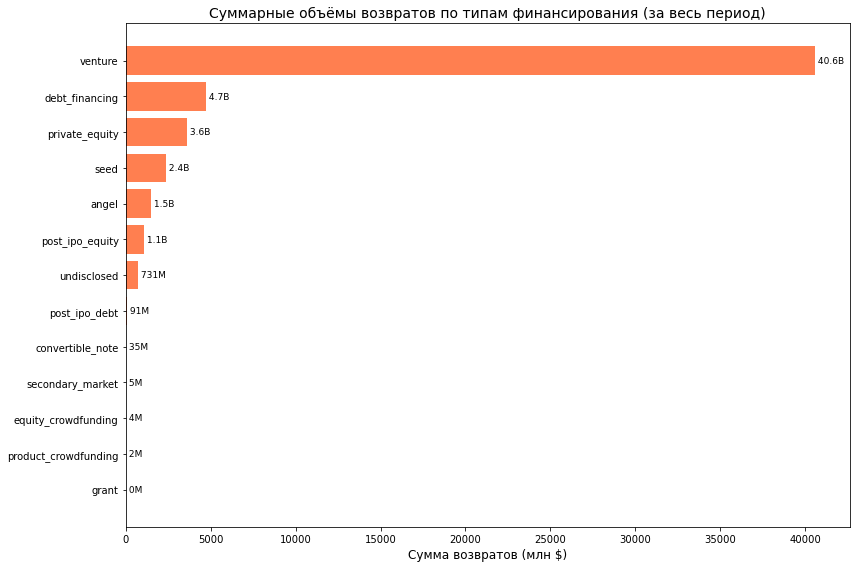

In [56]:
# Суммируем по каждому типу за все годы
total_returns = df_returns[return_types].sum().sort_values(ascending=True)
plt.figure(figsize=(12, 8))
bars = plt.barh(total_returns.index, total_returns.values, color='coral')
# Напшем функцию для форматирования подписей
def format_millions(value):
    if value >= 1000:
        return f'{value/1000:.1f}B'
    else:
        return f'{value:.0f}M'
# Напишем цикл для подписи баров
for bar, value in zip(bars, total_returns.values):
    plt.text(value, bar.get_y() + bar.get_height()/2, 
             f' {format_millions(value)}', 
             va='center', ha='left', fontsize=9)
plt.title('Суммарные объёмы возвратов по типам финансирования (за весь период)', fontsize=14)
plt.xlabel('Сумма возвратов (млн $)', fontsize=12)
plt.tight_layout()
plt.show()

Как видно из визуализации, венчурные инвестиции являются лидерами по возвратам, порядка 40 млрд долларов было возвращено. 

Примерно половина из всех типов финансирования имеет заметный объём возвратов, остальная половина либо имеет очень малую сумму возвратов, либо вообще не имеет, как, например, тип `grant`.

Это говорит о том, что рискованные инвестиции являются доминирующим типом инвестиций в стартапы, у них же самый большой объём вложенных средств. Это доказывает то, что для инновационных компаний характерны крупные чеки, длинный цикл и высокий потенциал роста.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитаем для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы построим графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

Когда будем строить графики в этом задании и следующих, используем данные только по тем компаниям, которые остались в датасете после предыдущих фильтраций.

На основе полученных данных ответим на вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

In [57]:
# Рассчитываем средний объём одного раунда для каждой компании
df_final['avg_round_size'] = df_final['funding_total_usd'] / df_final['funding_rounds']
# Возьмем год из 'mid_funding_at'
df_final['funding_year'] = df_final['mid_funding_at'].dt.year

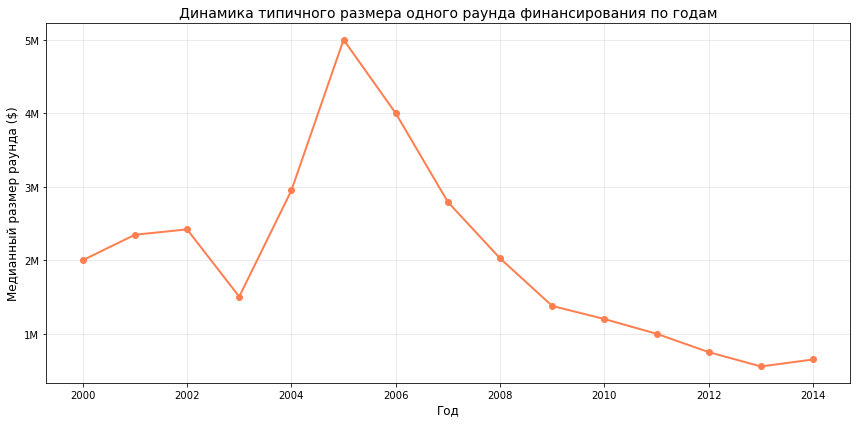

In [58]:
# Сгруппируем по годам и посчитаем медианный размер раунда
yearly_avg_round = df_final.groupby('funding_year')['avg_round_size'].median()
# Строим график типичного размера одного раунда финансирования по годам
plt.figure(figsize=(12, 6))
plt.plot(yearly_avg_round.index, yearly_avg_round.values, marker='o', linewidth=2, markersize=6, color='coral')
plt.title('Динамика типичного размера одного раунда финансирования по годам', fontsize=14)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Медианный размер раунда ($)', fontsize=12)
plt.grid(True, alpha=0.3)
# Напишем функцию, которая отформатирует значения оси Y
def format_Y(value, _):
    if value >= 1e6:
        return f'{value/1e6:.0f}M'
    return f'{value/1e3:.0f}K'
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_Y))
plt.tight_layout()
plt.show()

Данный график отражает тенденцию типичного размера одного раунда финансирования по каждому году, начиная с 2000 и заканчивая 2014. Как мы видим, в 2005 году наблюдался максимальный типичный размер средств, собранных в рамках одного раунда. Кроме того, визуализация наглядно демострирует тот факт, что с 2005 года по 2013 год включительно медианный размер раунда постоянно уменьшался (виден ярко выраженный нисходящий тренд). Только в 2014 году ситуация немного улучшилась в пользу увеличения размера раунда.

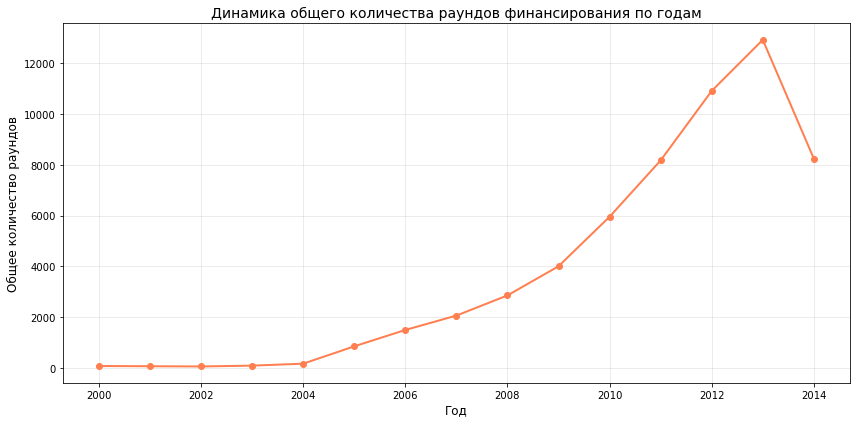

In [59]:
# Считаем общее количество раундов (суммируем funding_rounds по годам)
yearly_total_rounds = df_final.groupby('funding_year')['funding_rounds'].sum()
# Строим график общего количества раундов финансирования по годам
plt.figure(figsize=(12, 6))
plt.plot(yearly_total_rounds.index, yearly_total_rounds.values, marker='o', linewidth=2, markersize=6, color='coral')
plt.title('Динамика общего количества раундов финансирования по годам', fontsize=14)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Общее количество раундов', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Итак, на данном линейном графике чётко видно, что к 2013 году был исключительно восходящий тренд по общему количеству раундов. Однако, к 2014 году произошел резкий спад числа раундов финансирования: значение упало до примерно значения 2011 года. То есть в 2014 году инвесторы менее часто в среднем хотели инвестировать в стартапы. Нужны дополнительные данные, чтобы разобраться, почему именно это произошло.

Сравнивая оба графика невозможно не заметить то, что при увеличении общего количества раундов финансирования по годам, медианный размер одного раунда финансирования уменьшался. То есть фактически отрицательная корреляция между количеством раундов и медианным размером одного раунда свидетельствует о том, что компании с большим числом раундов финансирования, как правило, привлекают меньшие суммы за один раунд. Это может указывать на две стратегии: либо компании используют постепенное финансирование (небольшими траншами), либо сталкиваются с трудностями при привлечении крупных раундов и вынуждены брать небольшие (по размеру) раунды.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составим сводную таблицу, в которой укажем суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберем из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразим, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у нас достаточно данных. Рассмотрим только массовые сегменты, а средние и нишевые исключим.

На основе графика сделаем вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост.

In [60]:
# Так как есть значения-загдушки в столбце с сегментами, удалим их для этой задачи
df_final_clean = df_final[~df_final['market'].str.lower().isin(['uknown'])].copy()
print(f'Длина датафрейма после удаления ненужных строк: {len(df_final_clean)}')

Длина датафрейма после удаления ненужных строк: 33479


После удаления индикаторов (бывших пропусков) осталось 33479 строк.

In [61]:
# Оставим только массовые сегменты из предобработанного датасета 'df_final'
mass_segments = df_final_clean[~df_final_clean['market'].isin(['mid', 'niche'])]['market'].unique()
# Создаём сводную таблицу
pivot_funding = pd.pivot_table(df_final_clean, values='funding_total_usd', index='funding_year', columns='market', aggfunc='sum', 
fill_value=0)
# Оставляем только массовые сегменты
pivot_mass = pivot_funding[mass_segments]
print('Суммарное финансирование по годам и массовым сегментам:')
print(pivot_mass.head(10))

Суммарное финансирование по годам и массовым сегментам:
market        Education  Social Media  Biotechnology  Hardware + Software  \
funding_year                                                                
2000                  0             0              0                    0   
2001             200000        650000              0                    0   
2002            1469542             0              0              8000000   
2003            2500000          5000       25262631             15399186   
2004                  0             0      122766544             18440000   
2005            6101000      14780000      409689486            340331327   
2006           12061823      54719980      908269603            307884914   
2007           16188000      82297192     1065529396            407717103   
2008           69747747      75816547     1077232699            256153245   
2009           35566318      40016760     2991629225            531231284   

market        Enter

In [62]:
# Проверим, есть ли данные за 2013 и 2014
if 2013 in pivot_mass.index and 2014 in pivot_mass.index:
    growth_2014 = pivot_mass.loc[2014] - pivot_mass.loc[2013]
    growing_segments = growth_2014[growth_2014 > 0].index.tolist()
    print(f'Сегменты с ростом в 2014 году: {len(growing_segments)}')
    print(growing_segments)
else:
    print('Нет данных за 2013 или 2014 год')
    growing_segments = []

Сегменты с ростом в 2014 году: 11
['Manufacturing', 'Medical', 'Design', 'Technology', 'Photography', 'Internet', 'Entertainment', 'SaaS', 'Marketplaces', 'Startups', 'Apps']


In [63]:
if growing_segments:
    pivot_growing = pivot_mass[growing_segments]
    print('Сводная таблица для растущих сегментов:')
    print(pivot_growing)
else:
    print('Нет сегментов с ростом в 2014 году')

Сводная таблица для растущих сегментов:
market        Manufacturing    Medical    Design  Technology  Photography  \
funding_year                                                                
2000               56659310   24000000         0           0            0   
2001                2368582          0         0    22160000            0   
2002                      0          0         0     8500000            0   
2003                4269608          0         0     2500000            0   
2004               29000000          0         0     1750000      7100000   
2005               50660000   11090000   9300000    42476000      2000000   
2006               90379529   20250000    707000    28177425     11686406   
2007              153190008    2100000  10800000   124856209     10764586   
2008              123868732   28812744    344302   230770502     23659381   
2009              352719349   13805120   2150144    34743999     12922378   
2010              316173065   123764

Только 11 сегментов из 48 массовых показывают рост размера суммарного финансирования в 2014 году по сравнению с 2013.

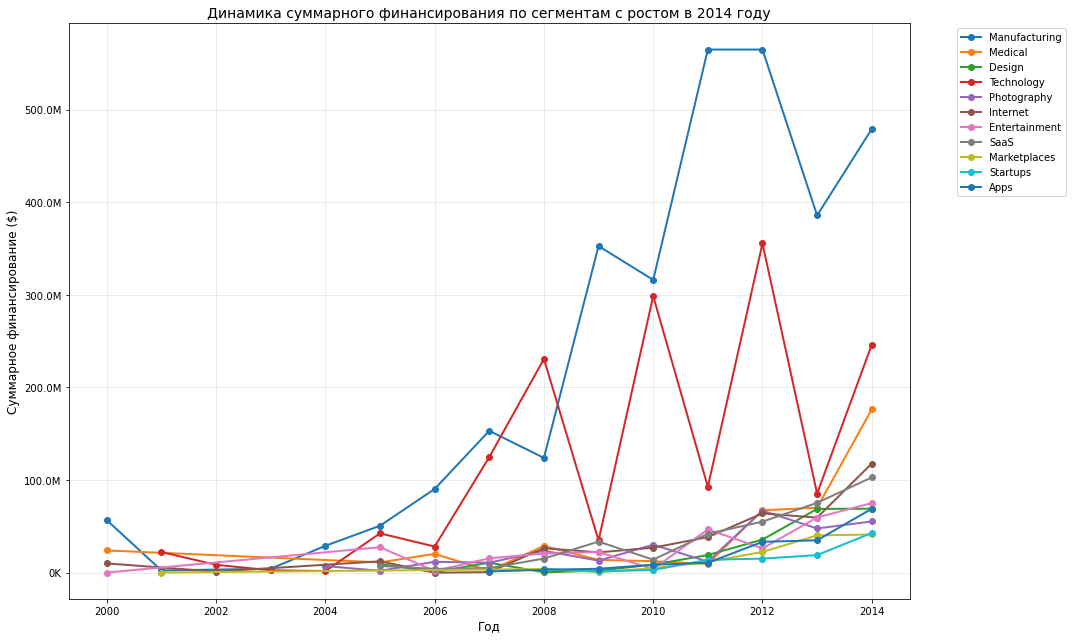

In [64]:
# Строим график суммарного финансирования по сегментам с ростом в 2014 году
plt.figure(figsize=(15, 9))    
for segment in growing_segments:
    data = pivot_growing[segment]
    data = data[data > 0]
    plt.plot(data.index, data.values, marker='o', linewidth=2, label=segment)    
plt.title('Динамика суммарного финансирования по сегментам с ростом в 2014 году', fontsize=14)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Суммарное финансирование ($)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)    
# Напишем цикл, который форматирует ось Y
def format_Y(value, _):
    if value >= 1e6:
        return f'{value/1e6:.1f}M'
    return f'{value/1e3:.0f}K'    
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_Y))
plt.tight_layout()
plt.show()

На основе графика можно сделать вывод о том, что из 11 отобранных массовых сегментов из общей картины выбиваются 2 (остальные имеют очень похожую динамику): `Manufacturing` и `Technology`. Первый сегмент показывает монотонный рост суммарного финансирования в период с 2003 по 2007 годы (рост продолжался до отметки примерно в 150 млн долларов), а далее растет с коррекциями, но при этом каждый следующий рост кратно превосходит прошлое падение. Однако в период с 2011 по 2012 год наблюдается плато. Затем резкое падение и вновь рост.

У сегмента `Technology` с 2006 года по 2014 год видны сильные колебания суммы финансирования, но глобально с небольшим восходящим трендом. В 2014 году общий размер инвестиций не перебил исторический максимум в 350 млн долларов в 2012 году. 

Рассмотрев график, ясно следующее: сегменты `Manufacturing` и `Technology` обладают крайне высокой волатильностью в области суммарного финансирования по сравнению с другими 9 массовыми сегментами. Это говорит о капиталоёмкости проектов в этих отраслях, наличии крупных игроков, искажающих статистику, а также на повышенные инвестиционные риски, требующие более осторожного подхода при оценке.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Наша цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.

Постройте график, на котором отобразите нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

Сделайте вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.

Доля возвратов после замены выбросов на NaN:           seed   venture  equity_crowdfunding  undisclosed  convertible_note  \
2000  1.557234  0.271793                  0.0     0.697042      0.000000e+00   
2001  0.338494  0.161984                  0.0     0.387509      1.000000e+64   
2002  0.949541  1.447341                  0.0     1.150446      2.000000e+64   
2003  1.584307  0.831988                  0.0     0.561221      1.000000e+64   
2004  0.543671  0.834415                  0.0     0.566719      1.478014e-03   

      debt_financing     angel  grant  private_equity  post_ipo_equity  \
2000        2.165000  0.272342    0.0        0.000000     9.400000e+65   
2001        2.245000  1.119574    0.0        0.000000     4.600000e+65   
2002             NaN       NaN    0.0        0.201333     1.133333e+00   
2003        0.250575  0.516667    0.0             NaN     2.110000e+66   
2004        0.531373  1.390256    0.0        0.182500     3.380000e+66   

      post_ipo_debt  secondar

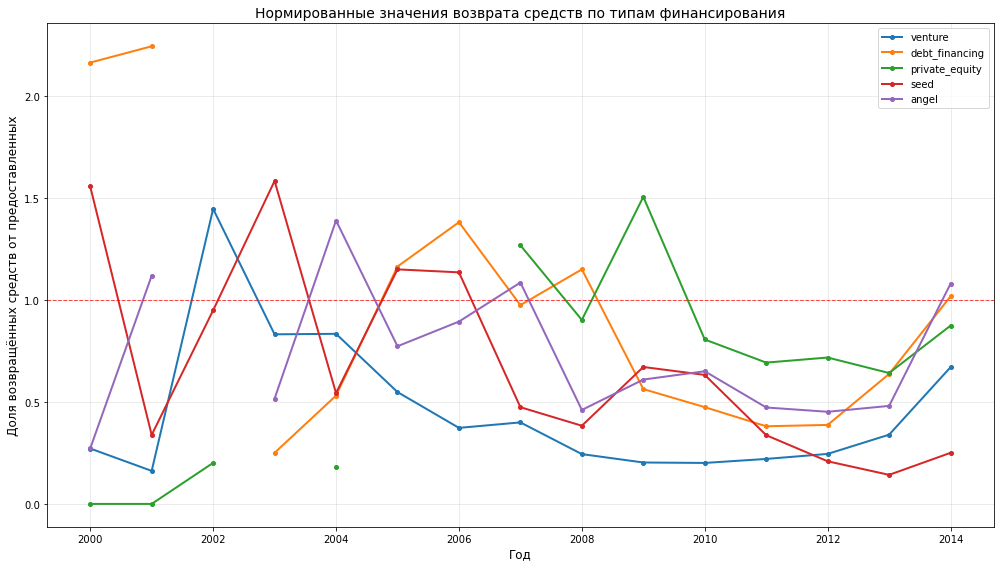

In [66]:
# 1-ая часть
df_final_clean['funding_year'] = df_final_clean['mid_funding_at'].dt.year

# Оставляем только те типы, которые есть в датасете
available_invest = [col for col in funding_types if col in df_final_clean.columns]

# Суммируем инвестиции по годам для каждого типа
invest_by_year = df_final_clean.groupby('funding_year')[available_invest].sum()

# Приводим названия столбцов к нижнему регистру
df_returns.columns = df_returns.columns.str.lower()

# Типы финансирования в датасете возвратов
invest_returns = [col for col in funding_types if col in df_returns.columns]

# Находим общие годы в обоих датасетах
common_years = sorted(set(invest_by_year.index) & set(df_returns.index))

# Обрезаем датасеты до общих годов
invest_aligned = invest_by_year.loc[common_years]

# Возвраты переводим из миллионов в доллары
returns_aligned = df_returns.loc[common_years] * 1_000_000

a= 1e-60
return_ratio = pd.DataFrame(index=common_years)

for inv_type in invest_returns:
    if inv_type in invest_aligned.columns:
        invest = invest_aligned[inv_type]
        returns = returns_aligned[inv_type]
        ratio = returns / (invest + a)
        ratio = ratio.replace([np.inf, -np.inf], np.nan)
        return_ratio[inv_type] = ratio

# Напишем функцию, которая заменяет выбросы на NaN
def replace_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 3 * iqr
    upper_bound = q3 + 3 * iqr
    return series.where((series >= lower_bound) & (series <= upper_bound), np.nan)
return_ratio_clean = return_ratio.copy()
for col in return_ratio.columns:
    clean_series = return_ratio[col].dropna()
    if len(clean_series) > 0:
        return_ratio_clean[col] = replace_iqr(return_ratio[col])
print(f'Доля возвратов после замены выбросов на NaN: {return_ratio_clean.head()}')

# Сохраняем итоговый датафрейм
df_return_ratio = return_ratio_clean.copy()

# Выберем нужные типы финансирования
selected_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

# 2-ая часть
# Строим график
plt.figure(figsize=(14, 8))
for funding_type in selected_types:
    plt.plot(df_return_ratio.index, df_return_ratio[funding_type], 
             marker='o', linewidth=2, markersize=4, label=funding_type)
plt.title('Нормированные значения возврата средств по типам финансирования', fontsize=14)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Доля возвращённых средств от предоставленных', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.axhline(y=1, color='red', linestyle='--', linewidth=1, alpha=0.7, label='100% возврат')
plt.tight_layout()
plt.show()

Роста показателя (устойчивого и долгого) не наблюдается ни у одного типа финансирования. Но при этом можно отметить, что с 2010 года тип `venture` неуклонно и монотонно рос. Тип `debt_financing` после падения начал расти с 2011 года. Все остальные типы имеют скорее нисходящую тенденцию на протяжении практически всего периода наблюдения.


## Шаг 5. Итоговый вывод и рекомендации

После проведенного масштабного анализа, можно сделать вывод о том, что лучше всего инвестировать в сегменты `Manufacturing` и `Technology`, если вы - крупный инвестор и готовы вкладывать достаточно много в фундаментальные инновации. Выбрав данные сегменты, вы должны быть уверены в стартапе, так как на рынке очень большая конкуренция. Однако, нет ничего плохого в том, чтобы вложить миллионы долларов в действительно стоящую и полезную для людей идею (например, IT-продукт, призванный упростить жизнь людям в том или ином плане).

Если же вы более консервативный инвестор и не желаете обременять себя излишними рисками, то стоит присмотреться к массовым сегментам `Internet` и `Apps` за их стабильность и предсказуемость. Конечно, в данных отраслях прибыль не будет столь большой, как в предыдущих двух группах, но вы сможете более гарантированно получить профит с инвестирования в стартапы из этих сегментов. К тому же, к концу 2014 года они показали неплохой рост размера суммарного финансированияю

Настоятельно рекомендуется использовать тип финансирования `venture`, поскольку он является лидером по ежегодному обороту вариантом инвестирования. Кроме того, венчурные ивестиции наиболее популярны среди всех стартапов в 2000-2014 годах: более 23 тысяч комапний доверились именно ему, значит, данный тип финансирования стабилен и проверен временем, сопутствующие риски будут минимальны.

Были изучены предложенные датасеты для работы, а также предобработаны данные: удалены пустые строки, не несящие никакой информации о компаниях, установлены заглушки для пропусков, обработаны аномальные значения и выбросы. Затем были построены графики, отражающие различные показатели вопроса инвестирования в стартапы: от процента инвестиций от общего объёма привлечённых средств до динамики суммарного финансирования по массовым сегментам с ростом в 2014 году